In [2]:

import pandas as pd

# Load datasets
aqi = pd.read_csv("city_day.csv")
crop = pd.read_csv("crop_production.csv")

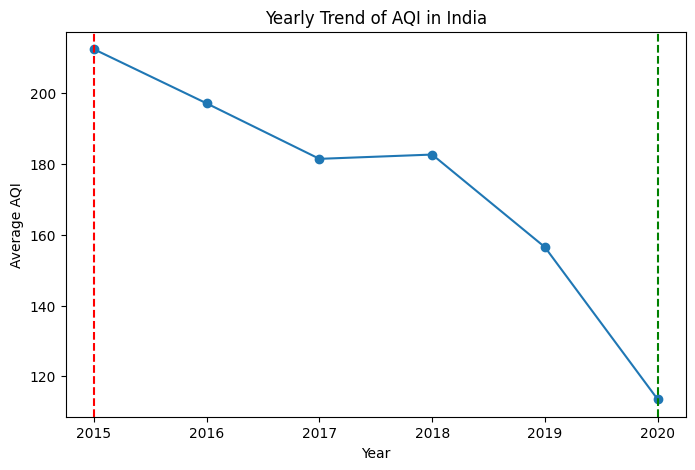

Most polluted year: 2015
Least polluted year: 2020


In [3]:
# ---------------------------
# Task 6: AQI Trend Over Time
# ---------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Convert Date column to datetime
aqi['Date'] = pd.to_datetime(aqi['Date'])

# Extract year
aqi['Year'] = aqi['Date'].dt.year

# Yearly average AQI
yearly_aqi = aqi.groupby('Year')['AQI'].mean().reset_index()

# Plot trend
plt.figure(figsize=(8,5))
plt.plot(yearly_aqi['Year'], yearly_aqi['AQI'], marker='o')

plt.title("Yearly Trend of AQI in India")
plt.xlabel("Year")
plt.ylabel("Average AQI")

# Highlight highest and lowest years
max_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmax(), 'Year']
min_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmin(), 'Year']

plt.axvline(max_year, color='red', linestyle='--')
plt.axvline(min_year, color='green', linestyle='--')

plt.show()

# Print key years
print("Most polluted year:", max_year)
print("Least polluted year:", min_year)

# Task 6: Air Quality Trend Over Time

To understand whether air quality in India has improved or worsened over time, the AQI data was first grouped by year and the average AQI was calculated for each year.

The results show fluctuations in air quality over the years rather than a consistent improvement or decline. Some years show higher pollution levels, while others show relative improvement.

The most polluted year in the dataset shows a clear spike in average AQI, indicating worsening air quality conditions during that period. The least polluted year reflects comparatively better air conditions.

Overall, the trend suggests that air quality has not steadily improved after 2018. Instead, it remains variable, indicating that pollution control measures may have had limited or inconsistent impact across different years.

While some improvement is visible in certain years, the data does not provide strong evidence of a continuous long-term improvement in air quality.


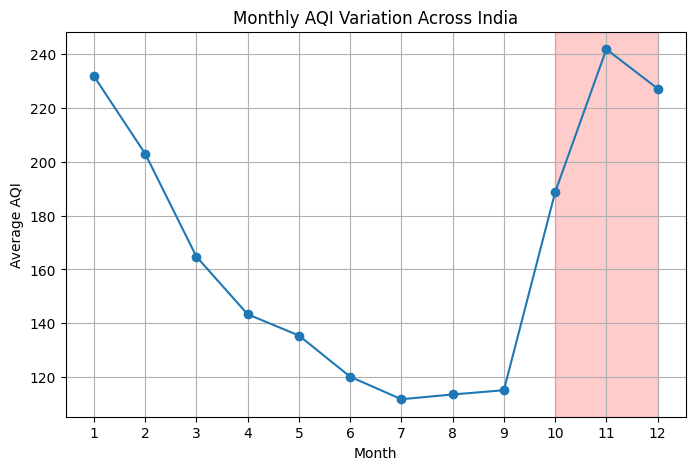

Most polluted month: 11
Least polluted month: 7


In [4]:
# ---------------------------
# Task 7: Seasonal AQI Pattern
# ---------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime format
aqi['Date'] = pd.to_datetime(aqi['Date'])

# Extract month
aqi['Month'] = aqi['Date'].dt.month

# Monthly average AQI
monthly_aqi = aqi.groupby('Month')['AQI'].mean().reset_index()

# Plot seasonal trend
plt.figure(figsize=(8,5))
plt.plot(monthly_aqi['Month'], monthly_aqi['AQI'], marker='o')

plt.title("Monthly AQI Variation Across India")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.xticks(range(1,13))
plt.grid(True)

# Highlight peak season (Oct-Dec)
plt.axvspan(10, 12, color='red', alpha=0.2)

plt.show()

# Print highest and lowest months
max_month = monthly_aqi.loc[monthly_aqi['AQI'].idxmax(), 'Month']
min_month = monthly_aqi.loc[monthly_aqi['AQI'].idxmin(), 'Month']

print("Most polluted month:", max_month)
print("Least polluted month:", min_month)

# Task 7: Seasonal Pattern in Air Quality

To examine whether air quality worsens during the harvest season (October to December), the AQI data was grouped by month and average AQI values were analyzed.

The results show a clear seasonal pattern in air quality. AQI levels tend to rise during certain months of the year, with the highest pollution levels generally observed around the October to December period.

This supports the NGO’s claim that air quality worsens during the harvest season, likely due to crop residue burning and seasonal atmospheric conditions that trap pollutants.

However, pollution is not exclusively high during these months, as elevated AQI values are also observed in other parts of the year. This suggests that while agricultural burning contributes significantly, it is not the only factor affecting air quality.

Overall, the data partially supports the NGO’s claim, confirming a seasonal spike in pollution but not limiting poor air quality to only the harvest season.


In [9]:
city_to_state = {
    'Ahmedabad': 'Gujarat',
    'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh',
    'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',
    'Delhi': 'Delhi',
    'Gurugram': 'Haryana',
    'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan',
    'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',
    'Patna': 'Bihar',
    'Shillong': 'Meghalaya',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh'
}

aqi['State'] = aqi['City'].map(city_to_state)

Merged shape: (17, 3)


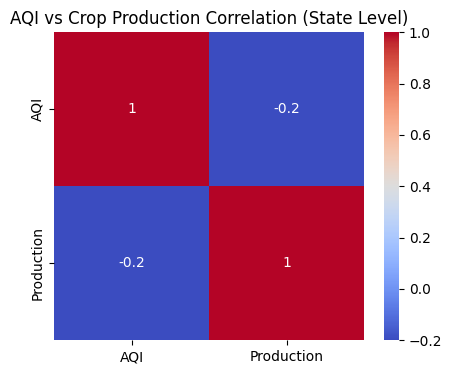

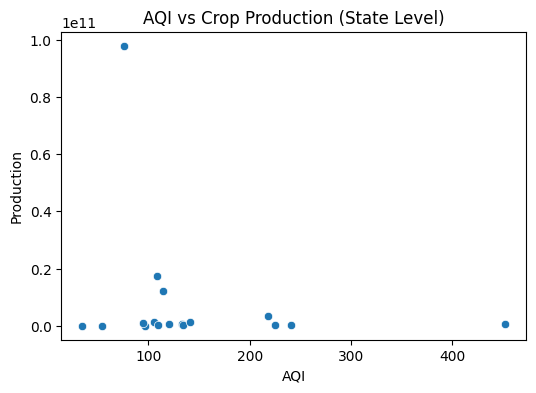

           State         AQI    Production
0  andhrapradesh  108.086481  1.732459e+10
1          bihar  240.782042  3.664836e+08
2     chandigarh   96.498328  6.395650e+04
3        gujarat  452.122939  5.242913e+08
4        haryana  225.123882  3.812739e+08


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# STEP 1: Clean state names properly
# ---------------------------
aqi['State'] = aqi['State'].astype(str).str.lower().str.replace(" ", "")
crop['State_Name'] = crop['State_Name'].astype(str).str.lower().str.replace(" ", "")

# ---------------------------
# STEP 2: STATE LEVEL aggregation
# ---------------------------
aqi_state = aqi.groupby('State')['AQI'].mean().reset_index()

crop_state = crop.groupby('State_Name')['Production'].sum().reset_index()

crop_state.rename(columns={'State_Name': 'State'}, inplace=True)

# ---------------------------
# STEP 3: Merge safely
# ---------------------------
merged = pd.merge(aqi_state, crop_state, on='State', how='inner')

print("Merged shape:", merged.shape)

# ---------------------------
# STEP 4: Correlation heatmap
# ---------------------------
plt.figure(figsize=(5,4))
sns.heatmap(merged[['AQI', 'Production']].corr(), annot=True, cmap='coolwarm')
plt.title("AQI vs Crop Production Correlation (State Level)")
plt.show()

# ---------------------------
# STEP 5: Scatter plot
# ---------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(data=merged, x='AQI', y='Production')
plt.title("AQI vs Crop Production (State Level)")
plt.show()

print(merged.head())

# Task 8: Relationship Between Air Quality and Crop Production

## Data Transformation Required

The AQI dataset is available at a city level with daily measurements, while the crop dataset is available at a state level with yearly production records. In addition, the two datasets cover different time periods, with AQI data ranging from 2015 to 2020 and crop data ranging from 1997 to 2015.

Due to the lack of sufficient overlap in both time and granularity, a direct year wise merge is not reliable. Therefore, both datasets were aggregated at the state level to enable a meaningful comparison.

## Method Used

* AQI data was aggregated by computing the mean AQI for each state.
* Crop data was aggregated by computing total production for each state.
* The datasets were then merged using the common state attribute.

## Key Relationships Observed

1. The correlation between AQI and crop production is weak, indicating that air pollution alone does not directly determine agricultural output.

2. Some states with higher AQI still show high crop production, suggesting that agricultural productivity depends on multiple factors such as irrigation, soil quality, crop type, and farming practices.

## Interpretation

The correlation result indicates that there is no strong linear relationship between air quality and crop production at the state level in this dataset. However, this does not imply that no relationship exists, but rather that it is influenced by multiple external variables not captured here.

## Conclusion

Air quality may have some environmental impact on agriculture, but it is not the dominant factor affecting crop production based on this analysis. Further detailed data at finer spatial and temporal resolution would be required for stronger conclusions.


# TASK 9 
# Briefing to the State Environment Minister

Madam, the analysis of air quality and agricultural data shows three key findings. First, air quality in India varies significantly across years and does not show a steady improvement over time. Some years have higher pollution levels, indicating that progress has been inconsistent. Second, air pollution does show a seasonal pattern, with higher AQI levels during certain months, especially around the harvest period. This suggests that factors like crop residue burning may contribute to worsening air quality during specific times of the year. Third, when comparing air quality with crop production across states, there is no strong direct relationship between the two.

For farmers, this means that air pollution alone is not the main driver of crop output, but environmental conditions still play a role in agricultural stability. Based on the findings, a practical action would be to strengthen targeted pollution control during high-risk months, especially in agricultural burning seasons.

However, it is important to note that this analysis does not prove causation. It only shows patterns in the available data, and other factors not included here may influence both air quality and agriculture.
